In [1]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
df = pd.read_csv(r'C:\Users\e.i.chapaev\Desktop\serious_udgu_pr\clearing_df.csv')
df

In [10]:
y = df['З/П']
X = df.drop(['З/П'], axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
model = CatBoostClassifier(
    iterations=500,           # для маленьких данных лучше меньше итераций + раннее стоппинг
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced', # Решает проблему дисбаланса 0 и 1
    eval_metric='F1',          # Оптимизируем под дисбаланс, а не под точность
    verbose=100,               # Выводить лог каждые 100 шагов
    random_seed=42
)

# 3. Обучение с защитой от переобучения
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50   # Остановится, если F1 перестанет расти
)

# 4. Получение вероятностей
y_proba = model.predict_proba(X_test)[:, 1]

# 5. Предсказание классов
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

0:	learn: 0.9523810	test: 0.6829268	best: 0.6829268 (0)	total: 1.02ms	remaining: 509ms
Stopped by overfitting detector  (50 iterations wait)

bestTest = 1
bestIteration = 8

Shrink model to first 9 iterations.
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         1.0       1.00      1.00      1.00         8

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



In [12]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 100.00%


In [13]:
print(f"Accuracy:{accuracy_score(y_test, y_pred):.3f}")
print(f"Precision:{precision_score(y_test, y_pred):.3f}")
print(f"Recall:  {recall_score(y_test, y_pred):.3f}")
print(f"F1-score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC:{roc_auc_score(y_test, y_proba):.3f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy:1.000
Precision:1.000
Recall:  1.000
F1-score: 1.000
ROC-AUC:1.000

Confusion Matrix:
 [[5 0]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         1.0       1.00      1.00      1.00         8

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



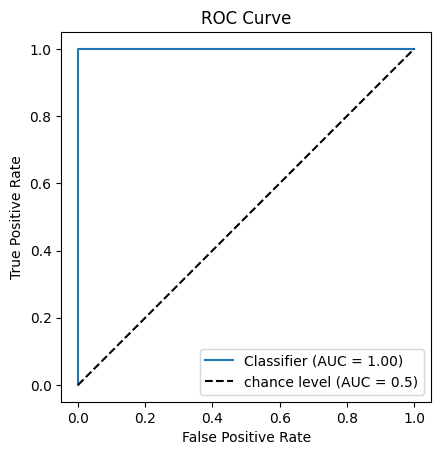

In [14]:
RocCurveDisplay.from_predictions(y_test, y_proba)

plt.plot([0, 1], [0, 1], "k--", label="chance level (AUC = 0.5)") 
plt.axis("square")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

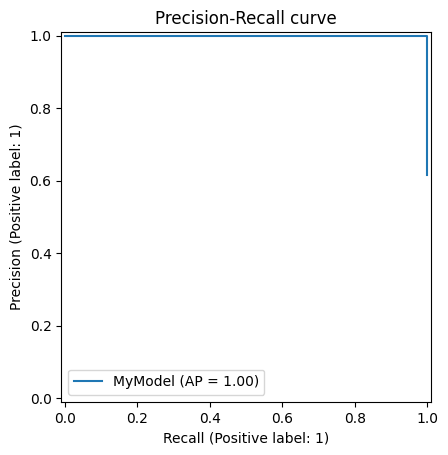

In [15]:
display = PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="MyModel")

_ = display.ax_.set_title("Precision-Recall curve")
plt.show()